In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import  gc, time
import numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
from scipy import sparse
import lightgbm as lgb
from sklearn.metrics import accuracy_score

SEED = 42

# utility
def seed_everything(seed=SEED):
    np.random.seed(seed)
seed_everything()

import warnings
warnings.filterwarnings('ignore')

# Dataset imported

In [4]:
TRAIN_PATH = "mentalHealth.csv"

train = pd.read_csv(TRAIN_PATH)
train

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Sai Menon,42,1/21/2025,Female,WhatsApp,254,64,0,1,7.7,35,1,5,7,At_Risk
4996,Neha Ansari,33,1/26/2025,Female,TikTok,330,214,1,2,7.4,27,3,7,6,Stressed
4997,Aarav Sharma,13,2/6/2025,Male,TikTok,403,262,2,2,7.0,20,4,9,4,Stressed
4998,Aadhya Patil,21,2/17/2025,Male,TikTok,476,309,2,3,6.6,12,4,9,4,Stressed


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

In [6]:
train.isnull().sum().sort_values(ascending=False)

,0
person_name,0
age,0
date,0
gender,0
platform,0
daily_screen_time_min,0
social_media_time_min,0
negative_interactions_count,0
positive_interactions_count,0
sleep_hours,0


# Exploratory Data Analysis

In [7]:
for x in train.columns:
    print(f'{train[x].value_counts()}\n')

person_name
Navya Chauhan       14
Avni Nair           13
Anika Chauhan       13
Aadhya Kulkarni     12
Anika Ghosh         12
                    ..
Aarohi Sharma        1
Vihaan Choudhary     1
Sai Saxena           1
Krishna Saxena       1
Krishna Gupta        1
Name: count, Length: 891, dtype: int64

age
19    265
21    265
23    262
24    242
22    242
20    240
25    234
31    163
32    152
29    145
33    145
35    144
28    138
34    135
27    130
26    127
30    121
16    111
13    109
15    101
18    101
17     94
45     87
42     87
14     84
37     84
36     80
43     73
41     72
39     71
40     66
38     66
44     64
57     29
49     28
58     27
55     26
52     26
62     25
50     25
63     24
68     24
64     22
66     20
67     20
69     20
60     20
47     20
51     19
54     19
61     19
65     16
48     16
59     15
53     15
46     14
56     11
Name: count, dtype: int64

date
11/6/2025     12
10/30/2025    12
1/10/2025     12
8/2/2024      12
11/15/2024    11
    

## Top 10 person used social media

In [ ]:
train.info()

In [8]:
top_user = train['person_name'].value_counts().nlargest(10).reset_index()
top_user.columns = ['person_name', 'count']
px.bar(
    top_user,
    x='person_name', y='count',
    title="Top 10 person used social media",
    color='count',
    color_continuous_scale='Viridis'
).show()

## Gender Distribution use social media

In [9]:
px.histogram(
    train,
    x='gender',
    nbins=20,
    title="Gender Distribution use social media",
    color_discrete_sequence=['teal']
).show()

## platform pie chart use social media

In [10]:
fig = px.pie(
    train.groupby("platform").size().reset_index(name="count"),
    names="platform",
    values="count",
    title="Mental State Distribution Using Social Media",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

In [11]:
cols = ['negative_interactions_count','positive_interactions_count','anxiety_level','stress_level','mood_level']

for col in cols:
    px.histogram(
        train,
        x=col,
        nbins=20,
        title=f"{col} Distribution",
        color_discrete_sequence=['teal']
    ).show()

## mental_state pie chart use social media

In [12]:
fig = px.pie(
    train.groupby("mental_state").size().reset_index(name="count"),
    names="mental_state",
    values="count",
    title="Mental State Distribution Using Social Media",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

# Data Preprocessing

In [13]:
from sklearn.metrics import  confusion_matrix, classification_report, make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import joblib

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler , LabelEncoder
from sklearn.pipeline import Pipeline

In [14]:
df = train.copy()

label_encoder = LabelEncoder()

cat_cols = df.select_dtypes(include=['object','category']).columns  # pick categorical columns

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

df.head()

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,630,35,0,1,1,320,160,1,2,7.4,28,2,7,6,2
1,553,24,6,0,1,453,226,1,3,6.7,15,3,8,5,2
2,164,26,54,1,2,357,196,1,2,7.2,24,3,7,6,2
3,540,66,16,0,2,190,105,0,1,8.0,41,2,6,6,2
4,625,31,40,1,2,383,211,1,2,7.1,22,3,7,6,2


In [15]:
cols = ['person_name','age','date','gender']
df = df.drop(columns=cols,axis=1)

In [16]:
X = df.drop(['mental_state'],axis=1)
y = df['mental_state']

X.describe()

,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.98480,373.058200,175.331600,0.864200,1.835400,7.134660,22.693400,2.510400,7.107600,5.625800
std,2.00992,106.003916,71.209329,0.555176,0.943443,0.533184,10.602862,0.794996,1.062378,0.759928
min,0.00000,140.000000,35.000000,0.000000,0.000000,6.400000,8.000000,1.000000,5.000000,4.000000
25%,1.00000,310.000000,118.000000,1.000000,1.000000,6.700000,14.000000,2.000000,6.000000,5.000000
50%,3.00000,388.000000,170.000000,1.000000,2.000000,7.100000,21.000000,3.000000,7.000000,6.000000
75%,5.00000,461.000000,231.000000,1.000000,2.000000,7.450000,29.000000,3.000000,8.000000,6.000000
max,6.00000,520.000000,338.000000,2.000000,4.000000,8.300000,46.000000,4.000000,9.000000,7.000000


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train.shape

(4000, 10)

In [18]:
numeric_features = list(X.select_dtypes(include=['int64', 'float64']).columns)

In [19]:
standard_scaler = StandardScaler()

X_train[numeric_features] = standard_scaler.fit_transform(X_train[numeric_features])

X_test[numeric_features] = standard_scaler.transform(X_test[numeric_features])

X_train.describe()

,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03
mean,3.197442e-17,2.220446e-17,1.842970e-16,1.287859e-17,1.207923e-16,-9.379164e-16,-6.217249e-17,-2.007283e-16,2.504663e-16,2.886580e-16
std,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00
min,-1.477293e+00,-2.207535e+00,-1.955996e+00,-1.559191e+00,-1.948980e+00,-1.382571e+00,-1.391689e+00,-1.895606e+00,-1.984251e+00,-2.134339e+00
25%,-9.783337e-01,-8.815572e-01,-8.059424e-01,2.433420e-01,-8.871548e-01,-8.177373e-01,-8.234886e-01,-6.410686e-01,-1.043290e+00,-8.219092e-01
50%,1.958414e-02,1.413397e-01,-7.663988e-02,2.433420e-01,1.746702e-01,-6.462634e-02,-1.605877e-01,6.134687e-01,-1.023295e-01,4.905207e-01
75%,1.017502e+00,8.232710e-01,7.823944e-01,2.433420e-01,1.746702e-01,8.767624e-01,8.811136e-01,6.134687e-01,8.386314e-01,4.905207e-01
max,1.516461e+00,1.391547e+00,2.279568e+00,2.045875e+00,2.298320e+00,2.194707e+00,2.206915e+00,1.868006e+00,1.779592e+00,1.802950e+00


## Hyperparameter Grids

In [20]:
param_distributions = {

    "rf": {
        "n_estimators": [100, 300, 500, 800],
        "max_depth": [None, 10, 20, 30, 50],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False]
    },

    "dt": {
        "criterion": ["gini", "entropy"],
        "max_depth": [ 20, 30, 50],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [1, 2, 4]
    },

    "xgb": {
        "n_estimators": [ 700, 900],
        "learning_rate": [0.05, 0.1],
        "max_depth": [ 7, 10],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "gamma": [1, 5],
        "min_child_weight": [1, 3, 5]
    },

    "lgb": {
        "num_leaves": [31, 63, 127],
        "max_depth": [10, 20],
        "learning_rate": [0.05, 0.1],
        "n_estimators": [500, 1000],
        "min_data_in_leaf": [10, 20, 30]
    }
}

## Model training

In [22]:
models = {
    "rf": RandomForestClassifier(),
    "dt": DecisionTreeClassifier(),
    "xgb": XGBClassifier(eval_metric="mlogloss", use_label_encoder=False),
    "lgb": LGBMClassifier(verbosity=-1)
}

best_models = {}

for name, model in models.items():
    print(f"\n🔍 Running RandomizedSearch for {name}...")

    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[name],
        n_iter=15,                  # number of random combinations
        scoring="accuracy",
        cv=3,
        n_jobs=-1,
        verbose=0, # Changed from -1 to 0 to fix the InvalidParameterError
        random_state=42
    )

    rs.fit(X_train, y_train)

    best_models[name] = rs.best_estimator_
    joblib.dump(rs.best_params_,f"best_{name}.pkl")

    print(f"➡ Best params for {name}: {rs.best_params_}")
    print(f"➡ Best score: {rs.best_score_:.4f}")


🔍 Running RandomizedSearch for rf...
➡ Best params for rf: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': False}
➡ Best score: 1.0000

🔍 Running RandomizedSearch for dt...
➡ Best params for dt: {'min_samples_split': 20, 'min_samples_leaf': 4, 'max_depth': 50, 'criterion': 'entropy'}
➡ Best score: 1.0000

🔍 Running RandomizedSearch for xgb...
➡ Best params for xgb: {'subsample': 0.6, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.6}
➡ Best score: 0.9995

🔍 Running RandomizedSearch for lgb...
➡ Best params for lgb: {'num_leaves': 63, 'n_estimators': 1000, 'min_data_in_leaf': 10, 'max_depth': 10, 'learning_rate': 0.05}
➡ Best score: 0.9997


In [23]:
final_models = [
    best_models["rf"],
    best_models["dt"],
    best_models["xgb"],
    best_models["lgb"],
]


models_name =["RandomForestClassifier","DecisionTreeClassifier","XGBClassifier","LGBMClassifier"]

In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)


def ComparisionResult(final_models, models_name, X_test, y_test, average='weighted'):
    """
    Compare models and return DataFrame with metrics.
    - average: for precision/recall/f1 and multiclass roc_auc ('macro'|'micro'|'weighted')
    """
    results = []
    for i, model in enumerate(final_models):
        name = models_name[i] if i < len(models_name) else f"Model_{i}"
        # predicted labels
        y_pred = model.predict(X_test)

        # Basic classification metrics (use average for multiclass)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average=average, zero_division=0)
        rec = recall_score(y_test, y_pred, average=average, zero_division=0)
        f1 = f1_score(y_test, y_pred, average=average, zero_division=0)

        # Confusion matrix and detailed report
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, cmap="seismic")
        plt.title(f'Confusion Matrix for {models_name[i]}', fontsize=14)
        plt.savefig(f'Confusion Matrix {models_name[i]}.png')
        plt.show()
        #report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # --- ROC AUC: try to obtain proper scores/probabilities ---
        roc_auc = None
        roc_note = ""
        y_score = None

        # Prefer predict_proba
        if hasattr(model, "predict_proba"):
            try:
                y_score = model.predict_proba(X_test)
            except Exception as e:
                roc_note += f" predict_proba failed: {e};"
                y_score = None

        # Fallback to decision_function
        if y_score is None and hasattr(model, "decision_function"):
            try:
                y_score = model.decision_function(X_test)
            except Exception as e:
                roc_note += f" decision_function failed: {e};"
                y_score = None

        # Compute roc_auc if we have y_score
        if y_score is not None:
            y_score = np.asarray(y_score)
            try:
                # binary case: y_score could be (n_samples,) or (n_samples,2) -> we use prob of positive class
                if y_score.ndim == 1:
                    roc_auc = roc_auc_score(y_test, y_score)
                elif y_score.ndim == 2 and y_score.shape[1] == 2:
                    # use probability of positive class (col 1)
                    roc_auc = roc_auc_score(y_test, y_score[:, 1])
                else:
                    # multiclass: pass entire matrix and set multi_class param
                    roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average=average)
            except ValueError as ve:
                # sometimes you need label-binarize or labels arg; include note
                roc_note += f" roc computation error: {ve}"
                # try binarizing as last resort (only if multiclass)
                try:
                    from sklearn.preprocessing import label_binarize
                    classes = np.unique(y_test)
                    Y_bin = label_binarize(y_test, classes=classes)
                    # if y_score columns match classes
                    if y_score.ndim == 2 and y_score.shape[1] == len(classes):
                        roc_auc = roc_auc_score(Y_bin, y_score, average=average)
                    else:
                        roc_note += " binarize fallback not applicable;"
                except Exception as e2:
                    roc_note += f" binarize fallback failed: {e2}"
        else:
            roc_note += " no predict_proba/decision_function available;"

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC_AUC": roc_auc,
        })

    return pd.DataFrame(results)

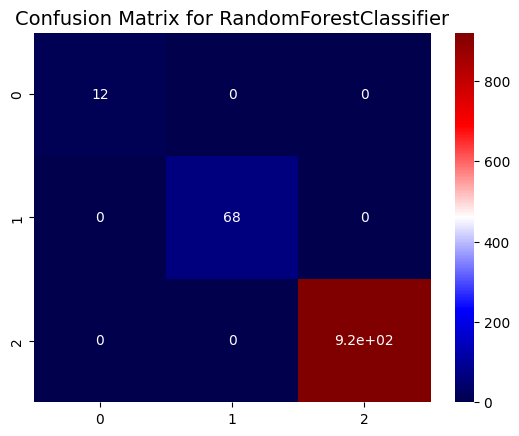

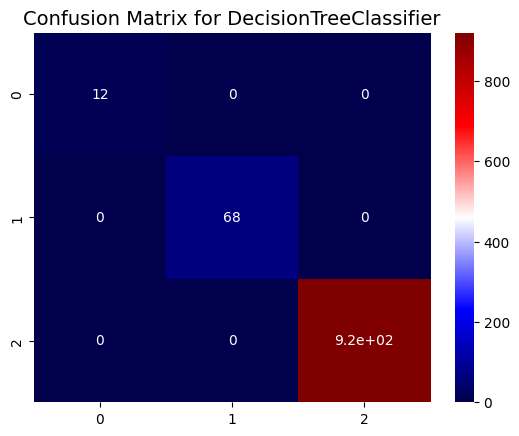

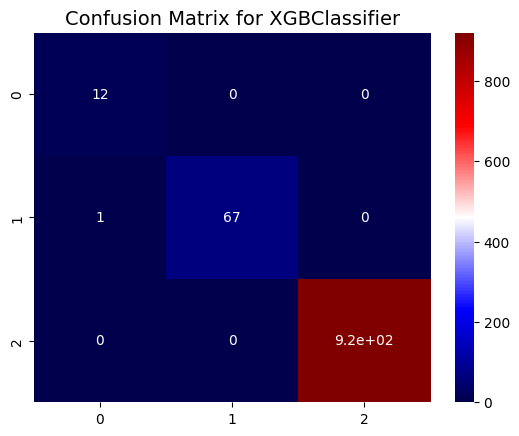

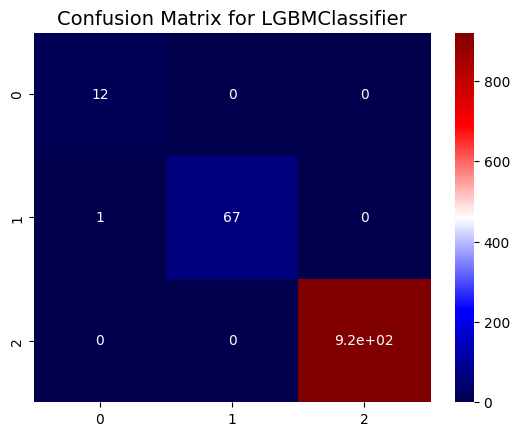


Models Performance Table 



,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForestClassifier,1.000,1.000000,1.000,1.000000,1.0
1,DecisionTreeClassifier,1.000,1.000000,1.000,1.000000,1.0
2,XGBClassifier,0.999,0.999077,0.999,0.999016,1.0
3,LGBMClassifier,0.999,0.999077,0.999,0.999016,1.0


In [25]:
Result_table1 = ComparisionResult(final_models, models_name, X_test, y_test, average='weighted')
print("\nModels Performance Table \n")
Result_table1[['Model','Accuracy','Precision','Recall','F1','ROC_AUC']]

## Voting Classifier (Hard + Soft)

```markdown
# Mental Health Prediction from Social Media Data

## Project Overview
This project aims to predict the mental state of individuals based on their social media usage patterns and related attributes. Using a dataset containing various features such as screen time, social media interaction counts, sleep hours, physical activity, anxiety, stress, and mood levels, we develop and evaluate several machine learning models to classify mental states into categories like 'Stressed', 'Healthy', and 'At_Risk'.

## Dataset
The dataset used in this project is `mentalHealth.csv`, which includes information about individuals' daily routines and their perceived mental state.

## Exploratory Data Analysis (EDA)
We performed an extensive EDA to understand the data distribution, identify patterns, and visualize key relationships. This involved:
- Analyzing the top social media users.
- Visualizing gender distribution across social media platforms.
- Exploring the distribution of social media platforms.
- Examining distributions of negative/positive interactions, anxiety, stress, and mood levels.
- Visualizing the overall distribution of mental states.

## Data Preprocessing
The following steps were taken to prepare the data for machine learning models:
- **Label Encoding**: Categorical features (`person_name`, `date`, `gender`, `platform`, `mental_state`) were converted into numerical representations using `LabelEncoder`.
- **Feature Selection**: Irrelevant columns such as `person_name`, `age`, `date`, and `gender` were dropped as they were either too high cardinality or deemed less relevant for direct prediction after encoding.
- **Data Splitting**: The dataset was divided into training and testing sets (80% train, 20% test) using stratified sampling to maintain the original class distribution in both sets.
- **Feature Scaling**: Numerical features were standardized using `StandardScaler` to ensure uniform scale across all features, which is crucial for many machine learning algorithms.

## Model Training and Evaluation
We trained and tuned several classification models using `RandomizedSearchCV` for hyperparameter optimization:
- **Random Forest Classifier**
- **Decision Tree Classifier**
- **XGBoost Classifier**
- **LightGBM Classifier**

The models were evaluated based on Accuracy, Precision, Recall, F1-score, and ROC-AUC. Confusion matrices were generated to visualize classification performance.

### Results of Individual Models
All individual models achieved exceptionally high scores:
| Model                  | Accuracy | Precision | Recall | F1       | ROC_AUC |
| :--------------------- | :------- | :-------- | :----- | :------- | :------ |
| RandomForestClassifier | 1.000    | 1.000000  | 1.000  | 1.000000 | 1.0     |
| DecisionTreeClassifier | 1.000    | 1.000000  | 1.000  | 1.000000 | 1.0     |
| XGBClassifier          | 0.999    | 0.999077  | 0.999  | 0.999016 | 1.0     |
| LGBMClassifier         | 0.999    | 0.999077  | 0.999  | 0.999016 | 1.0     |

## Ensemble Modeling (Voting Classifier)
To potentially improve robustness and generalization, we implemented both hard and soft Voting Classifiers by combining the predictions of the best-tuned individual models.

### Results of Ensemble Models
- **Voting Hard Score**: 0.999
- **Voting Soft Score**: 1.0

The soft voting classifier also achieved perfect scores across all metrics in its classification report and ROC curves.

## Conclusion
The models developed in this project demonstrate excellent performance in classifying mental states. The near-perfect scores indicate strong predictive capabilities on the given dataset. While these results are highly promising, further validation on new, unseen data would be beneficial to confirm generalization and rule out any potential overfitting or data leakage.
```

In [32]:
print("To upload this project to GitHub, execute the following commands in your Colab terminal:")
print("Note: Replace <https://github.com/barnavo05?tab=repositories> with your actual repository URL.")

commands = [
    "!git init",
    "!git add .",
    "!git commit -m \"Initial commit: Mental Health Prediction Project\"",
    "!git branch -M main",
    "!git remote add origin <https://github.com/barnavo05?tab=repositories>",
    "!git push -u origin main"
]

for cmd in commands:
    print(cmd)

To upload this project to GitHub, execute the following commands in your Colab terminal:
Note: Replace <https://github.com/barnavo05?tab=repositories> with your actual repository URL.
!git init
!git add .
!git commit -m "Initial commit: Mental Health Prediction Project"
!git branch -M main
!git remote add origin <https://github.com/barnavo05?tab=repositories>
!git push -u origin main


In [34]:
!git init
!git add .
!git commit -m "Initial commit: Mental Health Prediction Project"
!git branch -M main
!git remote add origin <https://github.com/barnavo05?tab=repositories>
!git push -u origin main

Reinitialized existing Git repository in /content/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@de179a1d269d.(none)')
/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `git remote add origin <https://github.com/barnavo05?tab=repositories>'
error: src refspec main does not match any
error: failed to push some refs to 'origin'


In [37]:
# 1. Set your Git identity
!git config --global user.email "barnavodey05@gmail.com"
!git config --global user.name "Barnavo Dey"

# 2. Re-initialize the repository (optional, but harmless if already initialized)
!git init

# 3. Add all files to the staging area
!git add .

# 4. Commit the changes (now with author identity set)
!git commit -m "Initial commit: Mental Health Prediction Project"

# 5. Set the main branch (if it's not already)
!git branch -M main

# 6. Add the remote origin, using a valid repository URL and proper quoting
# IMPORTANT: Replace <YOUR_REPOSITORY_URL_HERE> with your actual GitHub repository URL
# Example: !git remote add origin "https://github.com/your_username/your_repo_name.git"
!git remote add origin "https://github.com/barnavo05?tab=repositories" # Example: replace this with your actual repo URL

# 7. Push the changes to GitHub
!git push -u origin main

Reinitialized existing Git repository in /content/.git/
On branch main
nothing to commit, working tree clean
error: remote origin already exists.
fatal: protocol '<https' is not supported


In [26]:
from sklearn.ensemble import VotingClassifier

# Using your tuned best models
voting_hard = VotingClassifier(
    estimators=[
        ('rf', best_models['rf']),
        ('dt', best_models['dt']),
        ('xgb', best_models['xgb']),
        ('lgb', best_models['lgb']),
    ],
    voting='hard'
)

voting_soft = VotingClassifier(
    estimators=[
        ('rf', best_models['rf']),
        ('dt', best_models['dt']),
        ('xgb', best_models['xgb']),
        ('lgb', best_models['lgb']),
    ],
    voting='soft'
)

voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

print("Voting Hard Score:", voting_hard.score(X_test, y_test))
print("Voting Soft Score:", voting_soft.score(X_test, y_test))

Voting Hard Score: 0.999
Voting Soft Score: 1.0


## Confusion Matrix – VotingClassifier (Soft)

<Figure size 700x600 with 0 Axes>

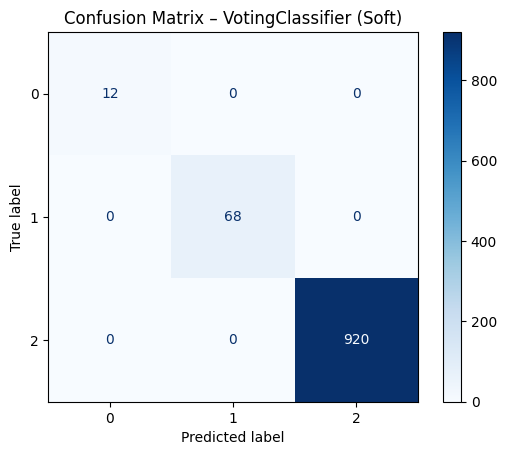

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = voting_soft.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – VotingClassifier (Soft)")
plt.show()

In [28]:
print("\nClassification Report (Voting Soft):\n")
print(classification_report(y_test, y_pred))


Classification Report (Voting Soft):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        68
           2       1.00      1.00      1.00       920

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## ROC Curve for All Models + Ensemble


===== Random Forest ===%%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        68
           2       1.00      1.00      1.00       920

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


===== Decision Tree ===%%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        68
           2       1.00      1.00      1.00       920

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


===== XGBoost ===%%
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.99      0.99        68


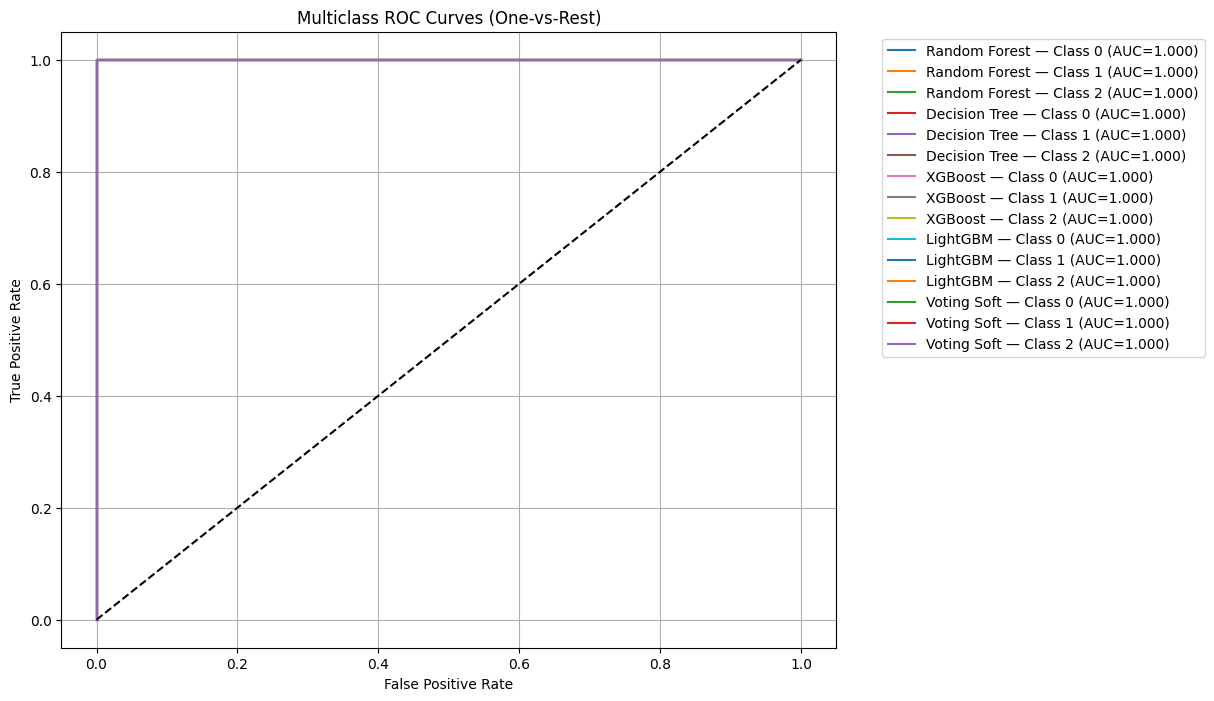

In [29]:
from sklearn.preprocessing import label_binarize
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]


plt.figure(figsize=(10, 8))

models = {
    "Random Forest": best_models['rf'],
    "Decision Tree": best_models['dt'],
    "XGBoost": best_models['xgb'],
    "LightGBM": best_models['lgb'],
    "Voting Soft": voting_soft
}

for model_name, model in models.items():

    # extract estimator if dict
    if isinstance(model, dict):
        model = model["best_estimator_"]

    # probability matrix: shape (n_samples, n_classes)
    y_prob = model.predict_proba(X_test)

    # Print classification report
    y_pred = np.argmax(y_prob, axis=1)
    print(f"\n===== {model_name} ===%%")
    print(classification_report(y_test, y_pred))

    # ---- Multiclass ROC (OvR) ----
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} — Class {classes[i]} (AUC={roc_auc:.3f})")

# Plot settings
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves (One-vs-Rest)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()